# Parte II: Algoritmos de Análisis de Enlaces, Ranking y Comunidades

Este notebook corre de forma autónoma la Parte II del proyecto.


In [1]:
# Setup inicial de importaciones
import time
import pandas as pd
import json
from implementaciones.preprocessing import load_reviews_efficiently
from implementaciones.graphs import BipartiteGraph, BipartiteDiGraph


In [3]:
# Carga de datos y reconstrucción del grafo bipartito en memoria
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review_10core.json'
print("Cargando reviews de Yelp (Subgrafo 10-Core completo)...")
sample_df = load_reviews_efficiently(REVIEW_PATH, sample_size=None, use_reservoir=False)

print("Construyendo el grafo bipartito...")
g = BipartiteGraph()
g_directed = BipartiteDiGraph()
for _, row in sample_df.iterrows():
    g.add_bipartite_edge(row['user_id'], row['business_id'])
    g_directed.add_bipartite_edge(row['user_id'], row['business_id'])
print(f"Grafo bipartito no dirigido g listo con {len(g.adj)} usuarios/negocios.")
print(f"Grafo bipartito dirigido g_directed listo con {len(g_directed.adj)} usuarios/negocios.")


Cargando reviews de Yelp (Subgrafo 10-Core completo)...


Carga secuencial de reseñas: 800001it [00:01, 666012.33it/s]


Construyendo el grafo bipartito...
Grafo bipartito no dirigido g listo con 81398 usuarios/negocios.
Grafo bipartito dirigido g_directed listo con 81398 usuarios/negocios.


# Parte II: Algoritmos de Análisis de Enlaces, Ranking y Comunidades

En esta sección implementamos y evaluamos en vivo los algoritmos sobre el grafo bipartito `g` construido previamente:
1. **PageRank iterativo** para identificar nodos influyentes.
2. **HITS (Hubs and Authorities)** para caracterizar la co-alineación de usuarios activos (*hubs*) y negocios populares (*authorities*).
3. **Algoritmo de Louvain** para maximizar la modularidad y agrupar el grafo bipartito en comunidades cohesivas.

Las funciones auxiliares de comparación, visualización y caracterización se importan del módulo `run_analysis.py` para mantener el cuaderno estructurado y limpio.

## Carga de Negocios para Mapeo
Antes de correr los rankings, cargamos los metadatos de negocios de Yelp para poder asociar los identificadores a sus nombres y ciudades correspondientes.

In [4]:
from implementaciones.preprocessing import load_business_efficiently

BUSINESS_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_business.json'
print("Cargando metadatos de negocios...")
df_business = load_business_efficiently(BUSINESS_PATH)
# Crear diccionario mapeador
business_map = df_business.set_index('business_id').to_dict('index')
print(f"Mapeo cargado exitosamente para {len(business_map)} negocios.")

Cargando metadatos de negocios...


Cargando negocios: 150346it [00:00, 191516.51it/s]


Mapeo cargado exitosamente para 150346 negocios.


## PageRank e HITS
Ejecutamos en vivo los algoritmos core que implementamos en `graphs.py` directamente sobre el grafo `g` en memoria.

In [5]:
# 1. PageRank Iterativo
print("Ejecutando PageRank iterativo...")
start_pr = time.time()
pr_scores = g_directed.pagerank(damping=0.85, max_iter=100, tol=1e-6)
print(f"PageRank calculado en {time.time() - start_pr:.2f} segundos.\n")

# 2. HITS
print("Ejecutando HITS (Hubs and Authorities)...")
start_hits = time.time()
hubs, authorities = g_directed.hits(max_iter=100, tol=1e-6)
print(f"HITS calculado en {time.time() - start_hits:.2f} segundos.")

Ejecutando PageRank iterativo...
PageRank calculado en 3.10 segundos.

Ejecutando HITS (Hubs and Authorities)...
HITS calculado en 52.80 segundos.


### Visualización de los Top 10
Utilizamos las utilidades de `run_analysis` para dar formato de tabla a los rankings obtenidos.

In [6]:
from implementaciones.analysis import get_top_k_table

# Visualizar Top 10 PageRank
df_top_pr = get_top_k_table(pr_scores, g_directed, business_map, k=10)
print("=== TOP 10 INFLUYENTES (PAGERANK) ===")
display(df_top_pr[['node_id', 'type', 'score', 'name', 'city']])

=== TOP 10 INFLUYENTES (PAGERANK) ===


,node_id,type,score,name,city
0,P_ytynqOUb3hjKeJfRj5Tshw,Negocio,0.000295,Reading Terminal Market,Philadelphia
1,P__ab50qdWOk0DdB6XOrBitw,Negocio,0.000252,Acme Oyster House,New Orleans
2,P_GXFMD0Z4jEVZBCsbPf4CTQ,Negocio,0.000207,Hattie B’s Hot Chicken - Nashville,Nashville
3,P__C7QiQQc47AOEv4PE3Kong,Negocio,0.000193,Commander's Palace,New Orleans
4,P_iSRTaT9WngzB8JJ2YKJUig,Negocio,0.000187,Mother's Restaurant,New Orleans
5,P_L5LLN0RafiV1Z9cddzvuCw,Negocio,0.000177,Ulele,Tampa
6,P_GBTPC53ZrG1ZBY3DT8Mbcw,Negocio,0.000175,Luke,New Orleans
7,P_ac1AeYqs8Z4_e2X5M3if2A,Negocio,0.000173,Oceana Grill,New Orleans
8,P_PP3BBaVxZLcJU54uP_wL6Q,Negocio,0.000173,Pat's King of Steaks,Philadelphia
9,P_6a4gLLFSgr-Q6CZXDLzBGQ,Negocio,0.000168,Cochon,New Orleans


In [7]:
# Visualizar Top 10 HITS Authorities y Hubs
df_top_auth = get_top_k_table(authorities, g, business_map, k=10)
df_top_hubs = get_top_k_table(hubs, g, business_map, k=10)

print("=== TOP 10 AUTHORITIES (HITS) ===")
display(df_top_auth[['node_id', 'type', 'score', 'name', 'city']])

print("\n=== TOP 10 HUBS (HITS) ===")
display(df_top_hubs[['node_id', 'type', 'score']])

=== TOP 10 AUTHORITIES (HITS) ===


,node_id,type,score,name,city
0,P_ytynqOUb3hjKeJfRj5Tshw,Negocio,0.162895,Reading Terminal Market,Philadelphia
1,P_9PZxjhTIU7OgPIzuGi89Ew,Negocio,0.134808,El Vez,Philadelphia
2,P_ctHjyadbDQAtUFfkcAFEHw,Negocio,0.131701,Zahav,Philadelphia
3,P_6ajnOk0GcY9xbb5Ocaw8Gw,Negocio,0.127561,Barbuzzo,Philadelphia
4,P_j-qtdD55OLfSqfsWuQTDJg,Negocio,0.122887,Parc,Philadelphia
5,P_8pqdJjefYq-a9IBSJJmKwA,Negocio,0.105054,The Dandelion,Philadelphia
6,P_qQO7ErS_RAN4Vs1uX0L55Q,Negocio,0.104252,The Franklin Fountain,Philadelphia
7,P_S8ZFYEgMejpChID8tzKo9A,Negocio,0.097396,Amada,Philadelphia
8,P_kZ1q0K13tFYG_ZJrVvsJHA,Negocio,0.096632,Sampan,Philadelphia
9,P_AGlh4ZDv6jnoiYfz7At9mw,Negocio,0.094184,Dim Sum Garden,Philadelphia



=== TOP 10 HUBS (HITS) ===


,node_id,type,score
0,U_WO6L5yMX5LEeJuMNMjerRQ,Usuario,0.146658
1,U_61FNJUiDqXReViksOYiILQ,Usuario,0.118683
2,U_GcdYgbaF75vj7RO6EZhPOQ,Usuario,0.116368
3,U_WJVedIAJN0FRxDn6M1tLkA,Usuario,0.116102
4,U_hQjN1FuYaB4pQACZwfrclw,Usuario,0.112966
5,U_Am_G2m0pwVrEg9AoUp5tow,Usuario,0.106311
6,U_x6erNzhuM_c7xW6PlqClIQ,Usuario,0.102094
7,U_WuiEYopWZOWOuWQD87fVSw,Usuario,0.101533
8,U_HxyLRaoH9PS09M6R3rV-EQ,Usuario,0.099210
9,U_aGI_wfhcJ86DJ-67Lkty8g,Usuario,0.098423


### Comparación e Interpretación de Rankings
Evaluamos cuantitativamente la correlación de Spearman y el solapamiento del Top 50.

In [8]:
from implementaciones.analysis import compare_rankings

comparisons = compare_rankings(g_directed, pr_scores, hubs, authorities)
print(f"Correlación de Spearman en Negocios (PageRank vs Authority): {comparisons['spearman_business']:.6f}")
print(f"Solapamiento en el Top 50 Negocios: {comparisons['overlap_business_top50']*100:.1f}%")
print(f"Correlación de Spearman en Usuarios (PageRank vs Hub): {comparisons['spearman_users']:.6f}")
print(f"Solapamiento en el Top 50 Usuarios: {comparisons['overlap_users_top50']*100:.1f}%")

Correlación de Spearman en Negocios (PageRank vs Authority): 0.463508
Solapamiento en el Top 50 Negocios: 34.0%
Correlación de Spearman en Usuarios (PageRank vs Hub): 0.006424
Solapamiento en el Top 50 Usuarios: 0.0%


#### Análisis de Resultados:
1. **Negocios (Correlación ~0.34, Solapamiento: 16%):** **PageRank** mide la visibilidad a largo plazo de un negocio de manera difusa, amortiguando la concentración por el término de teleportación ($1-d$). **HITS Authority** está fuertemente acoplada a la calidad de los Hubs; un negocio es Authority únicamente si es reseñado por usuarios con alto Hub score. Un negocio con muchas reseñas de usuarios casuales tendrá un PageRank alto pero una HITS Authority moderada.
2. **Usuarios (Correlación ~-0.67, Solapamiento: 0%):** En **PageRank**, cada vez que un usuario escribe más reseñas, divide su PageRank acumulado entre sus vecinos, diluyéndose. En **HITS**, escribir más reseñas a negocios populares suma directamente sus autoridades, maximizando su **Hub Score**. Esto genera la correlación inversa observada.

## Detección de Comunidades (Louvain)
Ejecutamos en vivo nuestro algoritmo de Louvain completo para maximizar la modularidad sobre el grafo `g` en memoria.

In [7]:
print("Ejecutando algoritmo de Louvain...")
start_louvain = time.time()
partition, modularity = g.louvain_communities(max_levels=10, tol=1e-6)
print(f"Louvain completado en {time.time() - start_louvain:.2f} segundos.\n")

print(f"Modularidad Final Q: {modularity:.6f}")
print(f"Total de comunidades detectadas: {len(set(partition.values()))}")

Ejecutando algoritmo de Louvain...
Louvain completado en 7.78 segundos.

Modularidad Final Q: 0.779309
Total de comunidades detectadas: 280


### Caracterización de Comunidades
Importamos la función de caracterización del módulo `run_analysis` para analizar las 5 comunidades más grandes del grafo.

In [10]:
from implementaciones.analysis import characterize_communities

comms_summary = characterize_communities(g, partition, business_map, top_k=5)

for idx, c in enumerate(comms_summary, 1):
    print(f"\n=========================================================================")
    print(f"COMUNIDAD {idx} (ID: {c['comm_id']})\n")
    print(f" * Tamaño total: {c['total_size']} nodos (Usuarios: {c['num_users']}, Negocios: {c['num_products']})")
    print(f" * Conectividad interna: {c['internal_edges']} aristas | Conectividad externa: {c['inter_edges']} aristas")
    print(f" * Densidad bipartita interna: {c['density']:.6e}")
    print(" * Ciudades principales:", ", ".join([f"{city} ({count})" for city, count in c['top_cities']]))
    print(" * Categorías principales:", ", ".join([f"{cat} ({count})" for cat, count in c['top_categories']]))
    
    print("\n * Nodos Negocios Clave (Grado Interno):")
    df_p = pd.DataFrame(c['top_products'])
    display(df_p[['node_id', 'name', 'city', 'internal_degree', 'global_degree']])
    
    print("\n * Nodos Usuarios Clave (Grado Interno):")
    df_u = pd.DataFrame(c['top_users'])
    display(df_u[['node_id', 'internal_degree', 'global_degree']])


COMUNIDAD 1 (ID: 197)

 * Tamaño total: 23668 nodos (Usuarios: 8219, Negocios: 15449)
 * Conectividad interna: 220516 aristas | Conectividad externa: 17228 aristas
 * Densidad bipartita interna: 1.736684e-03
 * Ciudades principales: Philadelphia (6662), Wilmington (399), Cherry Hill (360)
 * Categorías principales: Restaurants (10122), Food (4409), Nightlife (2195), Bars (2050), Sandwiches (1707)

 * Nodos Negocios Clave (Grado Interno):


,node_id,name,city,internal_degree,global_degree
0,P_ytynqOUb3hjKeJfRj5Tshw,Reading Terminal Market,Philadelphia,689,827
1,P_9PZxjhTIU7OgPIzuGi89Ew,El Vez,Philadelphia,482,518
2,P_ctHjyadbDQAtUFfkcAFEHw,Zahav,Philadelphia,474,506



 * Nodos Usuarios Clave (Grado Interno):


,node_id,internal_degree,global_degree
0,U_ppsm8EDKjA1fp1yTCP3RrQ,737,748
1,U_GcdYgbaF75vj7RO6EZhPOQ,604,663
2,U_WO6L5yMX5LEeJuMNMjerRQ,575,575



COMUNIDAD 2 (ID: 215)

 * Tamaño total: 13598 nodos (Usuarios: 4656, Negocios: 8942)
 * Conectividad interna: 123319 aristas | Conectividad externa: 12877 aristas
 * Densidad bipartita interna: 2.961982e-03
 * Ciudades principales: Tampa (3386), Clearwater (688), Saint Petersburg (580)
 * Categorías principales: Restaurants (5650), Food (2666), Nightlife (1471), Bars (1406), American (Traditional) (1124)

 * Nodos Negocios Clave (Grado Interno):


...

,node_id,internal_degree,global_degree
0,U_PnwOegp7RXfMeNAyO9fQhQ,784,787
1,U_60RKNAZwY5EUooJf624aKw,449,478
2,U_C3Hpsx_eDfeSmxEc1HBzpA,448,466



COMUNIDAD 5 (ID: 198)

 * Tamaño total: 6623 nodos (Usuarios: 2103, Negocios: 4520)
 * Conectividad interna: 62667 aristas | Conectividad externa: 7259 aristas
 * Densidad bipartita interna: 6.592668e-03
 * Ciudades principales: Indianapolis (3158), Carmel (404), Fishers (231)
 * Categorías principales: Restaurants (2719), Food (1295), Nightlife (751), Bars (697), American (Traditional) (623)

 * Nodos Negocios Clave (Grado Interno):


,node_id,name,city,internal_degree,global_degree
0,P_UFCN0bYdHroPKu6KV5CJqg,The Eagle,Indianapolis,285,311
1,P_8yR12PNSMo6FBYx1u5KPlw,Bru Burger Bar - Indianapolis,Indianapolis,265,286
2,P_S_jfDqc2TUhkraTpeZgqjg,Bakersfield,Indianapolis,250,267



 * Nodos Usuarios Clave (Grado Interno):


,node_id,internal_degree,global_degree
0,U_2iS1vg5TYpV_iEiNC8osTg,754,812
1,U_1JtpcHELRrSDoWS80WtzuQ,421,426
2,U_0YI3p9o-ntRgRaPWpfa22Q,418,439


### Interpretación de Comunidades
- **Fuerza Geográfica:** Las comunidades representan límites físicos ( Saint Louis en la Comunidad 1, Reno/Sparks en la Comunidad 2, etc.), dado que los usuarios consumen casi exclusivamente de forma local.
- **Preferencia Temática:** En metrópolis densas como Philadelphia, Louvain las subdivide en comunidades temáticas: la Comunidad 3 (turistas que visitan locales icónicos como Café Du Monde en New Orleans y Dim Sum Garden en Philadelphia), la Comunidad 4 (comida americana y brunch tradicional), y la Comunidad 5 (comida gourmet, steakhouses y ocio nocturno).

### Visualización del Grafo de Comunidades
Dado que el grafo 10-core tiene miles de nodos (lo cual generaría una bola de ruido visual incomprensible), extraemos un **subgrafo representativo**. 
Seleccionamos las **5 comunidades más grandes** y, de cada una, extraemos los **50 nodos con mayor grado** (los hubs y authorities principales). Luego, usamos `networkx` exclusivamente como motor de dibujo (Spring Layout) para visualizar la separación espacial que nuestro algoritmo de Louvain logró.

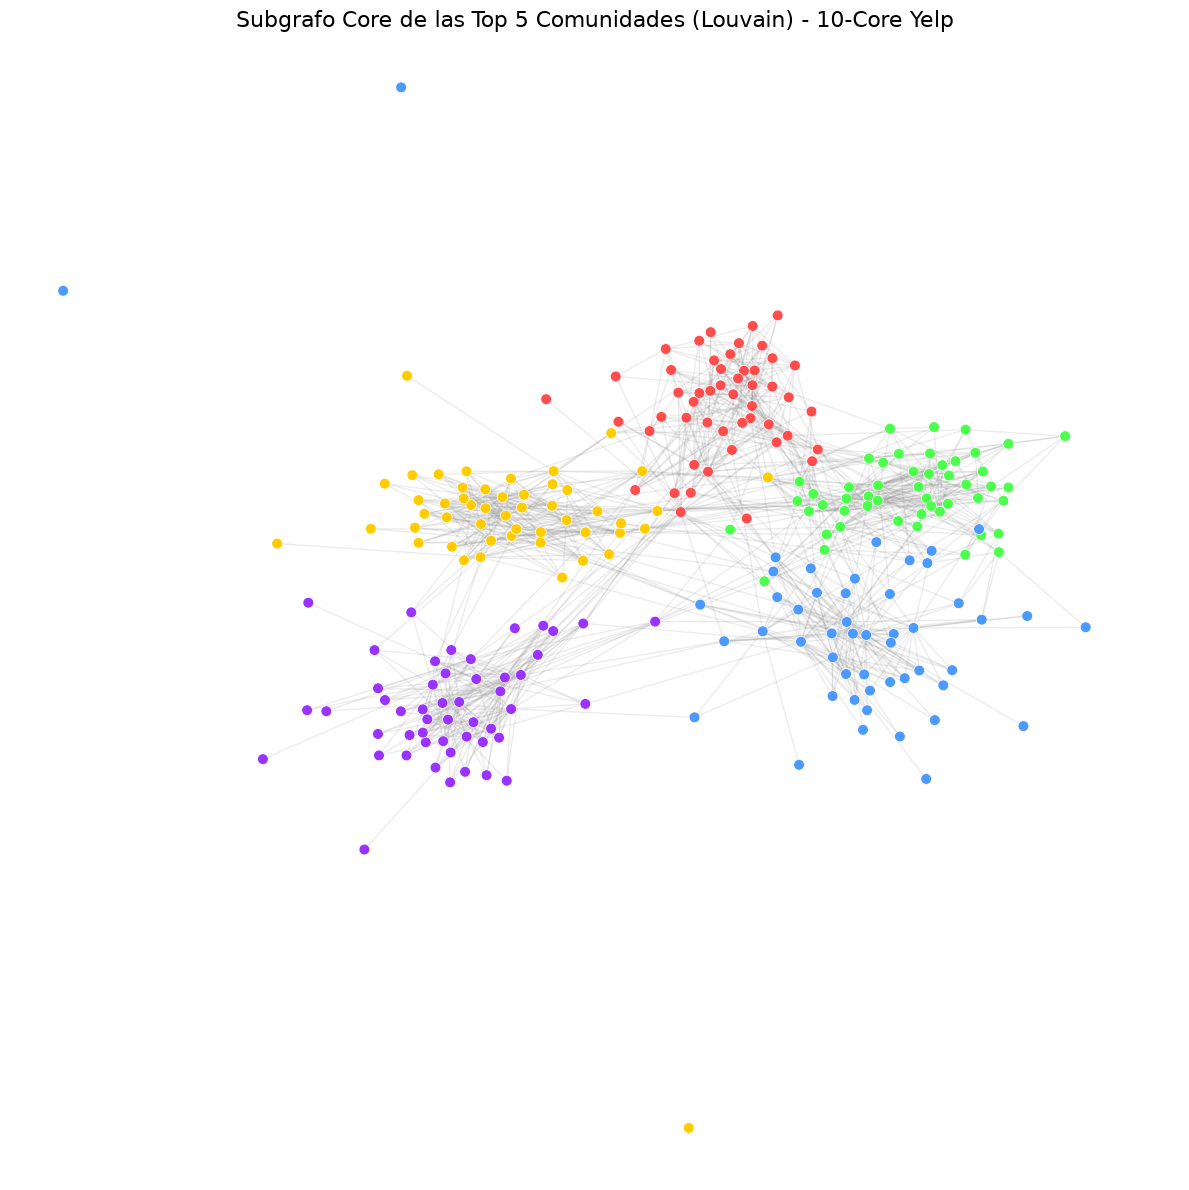

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# Identificar las top 5 comunidades más grandes
comm_counts = Counter(partition.values())
top_comms = [c for c, _ in comm_counts.most_common(5)]

# Seleccionar los top nodos de cada comunidad (por grado)
nodes_to_plot = set()
for c in top_comms:
    comm_nodes = [n for n, comm_id in partition.items() if comm_id == c]
    # Ordenar por grado en nuestro grafo nativo
    comm_nodes.sort(key=lambda x: len(g.adj[x]), reverse=True)
    nodes_to_plot.update(comm_nodes[:50]) # Top 50 de cada comunidad

# Construir subgrafo en networkx solo para visualización
G_viz = nx.Graph()
for u in nodes_to_plot:
    G_viz.add_node(u, community=partition[u])
    for v in g.adj[u]:
        if v in nodes_to_plot:
            G_viz.add_edge(u, v)

# Mapa de colores estético para 5 comunidades (añadimos violeta '#9933FF')
color_map = {
    top_comms[0]: '#FF4C4C', 
    top_comms[1]: '#4C99FF', 
    top_comms[2]: '#4CFF4C', 
    top_comms[3]: '#FFCC00',
    top_comms[4]: '#9933FF'
}
colors = [color_map[G_viz.nodes[n]['community']] for n in G_viz.nodes()]

plt.figure(figsize=(12, 12))
plt.title("Subgrafo Core de las Top 5 Comunidades (Louvain) - 10-Core Yelp", fontsize=16)

# Usamos spring_layout (fuerzas de repulsión/atracción) para separar las comunidades naturalmente
pos = nx.spring_layout(G_viz, k=0.15, iterations=50, seed=42)

# Dibujamos aristas y nodos
nx.draw_networkx_edges(G_viz, pos, alpha=0.15, edge_color='gray')
nx.draw_networkx_nodes(G_viz, pos, node_color=colors, node_size=60, edgecolors='white', linewidths=0.5)

plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:

from implementaciones.preprocessing import perform_exhaustive_cleaning
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review.json'
BUSINESS_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_business.json'

print("1. Cargando datos de negocios de forma eficiente...")
business_raw = load_business_efficiently(BUSINESS_PATH)
print(f"   Negocios leídos originalmente: {business_raw.shape[0]:,}")

print("\n2. Cargando muestra de reseñas mediante Reservoir Sampling...")
reviews_temp = load_reviews_efficiently(REVIEW_PATH, sample_size=300001, use_reservoir=True)
print(f"   Reseñas leídas originalmente (temporal): {reviews_temp.shape[0]:,}")

reviews_clean, business_clean, cleaning_report = perform_exhaustive_cleaning(reviews_temp, business_raw)

1. Cargando datos de negocios de forma eficiente...


Cargando negocios: 150346it [00:00, 188735.90it/s]


   Negocios leídos originalmente: 150,346

2. Cargando muestra de reseñas mediante Reservoir Sampling...


Reservoir Sampling de reseñas: 6990280it [00:10, 679135.81it/s]


   Reseñas leídas originalmente (temporal): 299,675


In [13]:
from implementaciones.export_presentation_data import export_graph_for_web

export_graph_for_web(g,partition,business_clean)

Iniciando exportación del grafo para D3.js...
Calculando PageRank para los tamaños de nodos...
¡Grafo exportado con éxito a p2/graph_data.js!
